In [1]:
!pip install scipy scikit-learn openpyxl

In [2]:
import pandas as pd
import numpy as np
import json

import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
from google.colab import files

uploaded = files.upload()

Saving dynamic_resume_scores.csv to dynamic_resume_scores.csv
Saving dynamic_pipeline_results.json to dynamic_pipeline_results.json


In [4]:
# Load files

dynamic_gt = pd.read_csv("CareerCorpus_DynamicGT.csv")

scores_df = pd.read_csv("dynamic_resume_scores.csv")

with open("dynamic_pipeline_results.json", "r") as f:
    json_results = json.load(f)

print("CareerCorpus DynamicGT Shape :", dynamic_gt.shape)
print("Dynamic Scores Shape :", scores_df.shape)
print("JSON Records :", len(json_results))

CareerCorpus DynamicGT Shape : (302, 12)
Dynamic Scores Shape : (302, 14)
JSON Records : 302


In [5]:
print("CareerCorpus DynamicGT Columns:")
print(dynamic_gt.columns)

print("\nDynamic Resume Scores Columns:")
print(scores_df.columns)

print("\nJSON Keys:")
print(json_results[0].keys())

CareerCorpus DynamicGT Columns:
Index(['ID', 'Domain', 'Education', 'Skills and Achievements', 'Experience',
       'Job_type', 'Annotator-1', 'Annotator-2', 'Resume_Text',
       'Weight_Annotator1', 'Weight_Annotator2', 'Dynamic_GT'],
      dtype='object')

Dynamic Resume Scores Columns:
Index(['Domain', 'Job_Level', 'Education_Score', 'Skills_Score',
       'Experience_Score', 'Certification_Score', 'Domain_Score',
       'Overall_Score', 'Dynamic_Final_Score', 'Education_Weight',
       'Skills_Weight', 'Experience_Weight', 'Certification_Weight',
       'Domain_Weight'],
      dtype='object')

JSON Keys:
dict_keys(['resume_id', 'domain', 'target_job', 'resume_evaluator', 'ceo_review', 'cto_review', 'hr_review', 'final_result', 'ground_truth_score', 'dynamic_weights', 'dynamic_final_score'])


In [6]:
# Convert Dynamic Ground Truth from 0-1 to 0-10

dynamic_gt["Dynamic_GT"] = dynamic_gt["Dynamic_GT"] * 10

dynamic_gt[["ID","Dynamic_GT"]].head()

,ID,Dynamic_GT
0,74552449,8.611765
1,79041971,6.439394
2,77156708,9.338889
3,24580361,9.022581
4,34953092,8.486956


In [7]:
# Add Dynamic Ground Truth (0-10 scale)

scores_df["ground_truth_score"] = dynamic_gt["Dynamic_GT"].values

# Rename Dynamic Final Score so the metrics code stays the same
scores_df["predicted_score"] = scores_df["Dynamic_Final_Score"]

scores_df[["predicted_score", "ground_truth_score"]].head()

,predicted_score,ground_truth_score
0,6.55,8.611765
1,6.00,6.439394
2,8.05,9.338889
3,6.45,9.022581
4,6.50,8.486956


In [9]:
# Verify there are no missing values

print("Missing Ground Truth:",
      scores_df["ground_truth_score"].isnull().sum())

print("Missing Predicted Score:",
      scores_df["predicted_score"].isnull().sum())

Missing Ground Truth: 0
Missing Predicted Score: 0


In [11]:
# Update JSON with Dynamic Ground Truth

for i, item in enumerate(json_results):

    item["ground_truth_score"] = float(
        dynamic_gt.loc[i, "Dynamic_GT"]
    )

print("JSON updated successfully!")

JSON updated successfully!


In [13]:
# Save updated JSON

with open(
    "dynamic_pipeline_results_dynamicGT.json",
    "w"
) as f:

    json.dump(
        json_results,
        f,
        indent=4
    )

print("Updated JSON saved successfully!")

Updated JSON saved successfully!


In [14]:
# Prepare arrays for evaluation

y_true = scores_df["ground_truth_score"].astype(float).values
y_pred = scores_df["predicted_score"].astype(float).values

print("Total Samples:", len(y_true))
print("Ground Truth Range:", y_true.min(), "to", y_true.max())
print("Prediction Range:", y_pred.min(), "to", y_pred.max())

Total Samples: 302
Ground Truth Range: 0.245945962600436 to 9.633333338888884
Prediction Range: 0.0 to 9.85


In [15]:
# Overall Pearson Correlation

pearson_corr, p_value = pearsonr(
    y_true,
    y_pred
)

print(f"Pearson Correlation : {pearson_corr:.4f}")
print(f"P-value             : {p_value:.6f}")

Pearson Correlation : 0.5675
P-value             : 0.000000


In [16]:
# Overall Spearman Correlation

spearman_corr, p_value = spearmanr(
    y_true,
    y_pred
)

print(f"Spearman Correlation : {spearman_corr:.4f}")
print(f"P-value              : {p_value:.6f}")


Spearman Correlation : 0.6442
P-value              : 0.000000


In [17]:
# ------------------------------------------------------------
# Percentile Metrics
# ------------------------------------------------------------

def percentile_metrics(df, percentile):

    gt = df["ground_truth_score"]
    pred = df["predicted_score"]

    lower = np.percentile(gt, percentile)
    upper = np.percentile(gt, 100 - percentile)

    subset = df[
        (gt <= lower) |
        (gt >= upper)
    ]

    pc, _ = pearsonr(
        subset["ground_truth_score"],
        subset["predicted_score"]
    )

    sc, _ = spearmanr(
        subset["ground_truth_score"],
        subset["predicted_score"]
    )

    return pc, sc

In [18]:
# ------------------------------------------------------------
# Percentile-Based Correlation Metrics
# ------------------------------------------------------------

PC20, SC20 = percentile_metrics(scores_df, 20)

PC15, SC15 = percentile_metrics(scores_df, 15)

PC10, SC10 = percentile_metrics(scores_df, 10)

print(f"PC20 = {PC20:.4f}")
print(f"SC20 = {SC20:.4f}")

print()

print(f"PC15 = {PC15:.4f}")
print(f"SC15 = {SC15:.4f}")

print()

print(f"PC10 = {PC10:.4f}")
print(f"SC10 = {SC10:.4f}")

PC20 = 0.7088
SC20 = 0.7704

PC15 = 0.7177
SC15 = 0.7744

PC10 = 0.8607
SC10 = 0.8326


In [19]:
# ------------------------------------------------------------
# Error Metrics
# ------------------------------------------------------------

mae = mean_absolute_error(
    y_true,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_true,
        y_pred
    )
)

r2 = r2_score(
    y_true,
    y_pred
)

print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2:.4f}")

MAE  = 1.2927
RMSE = 1.6324
R²   = 0.2450


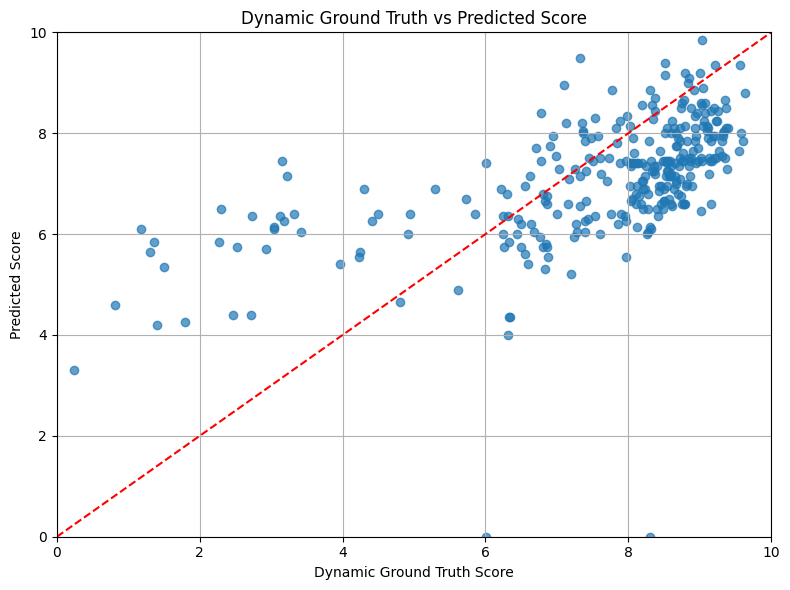

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(
    scores_df["ground_truth_score"],
    scores_df["predicted_score"],
    alpha=0.7
)

plt.plot([0,10], [0,10], 'r--')

plt.xlabel("Dynamic Ground Truth Score")
plt.ylabel("Predicted Score")
plt.title("Dynamic Ground Truth vs Predicted Score")

plt.xlim(0,10)
plt.ylim(0,10)

plt.grid(True)

plt.tight_layout()
plt.show()

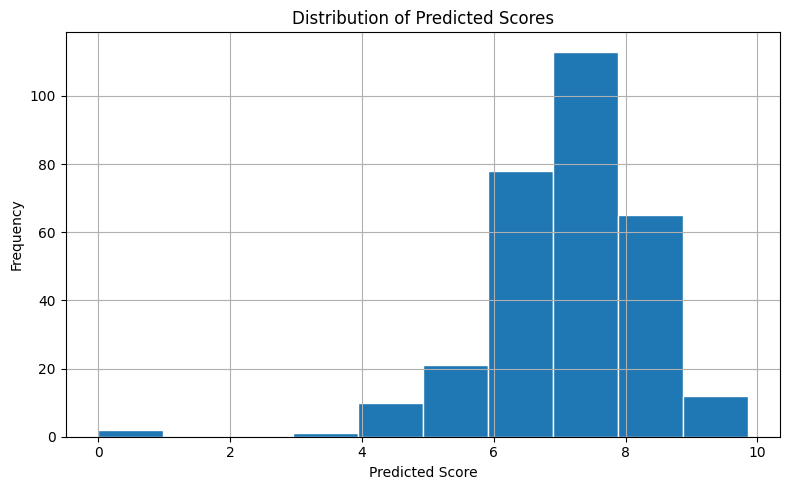

In [21]:
plt.figure(figsize=(8,5))

plt.hist(
    scores_df["predicted_score"],
    bins=10,
    edgecolor="white"
)

plt.xlabel("Predicted Score")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted Scores")

plt.grid(True)

plt.tight_layout()
plt.show()

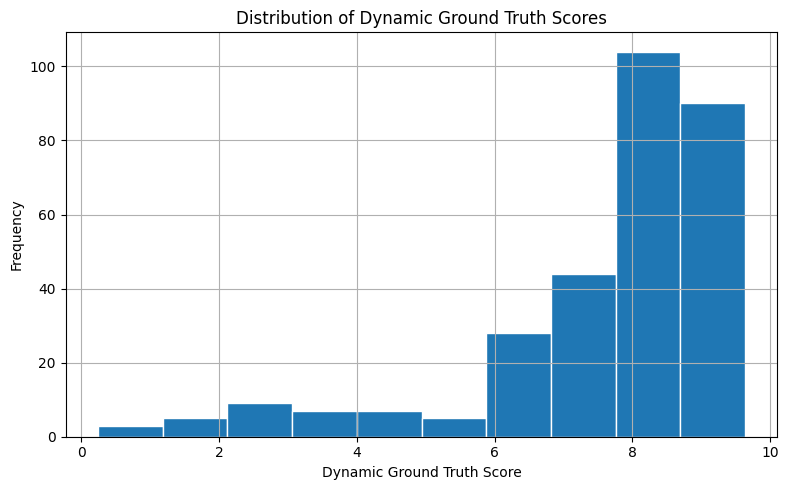

In [22]:
plt.figure(figsize=(8,5))

plt.hist(
    scores_df["ground_truth_score"],
    bins=10,
    edgecolor="white"
)

plt.xlabel("Dynamic Ground Truth Score")
plt.ylabel("Frequency")
plt.title("Distribution of Dynamic Ground Truth Scores")

plt.grid(True)

plt.tight_layout()
plt.show()

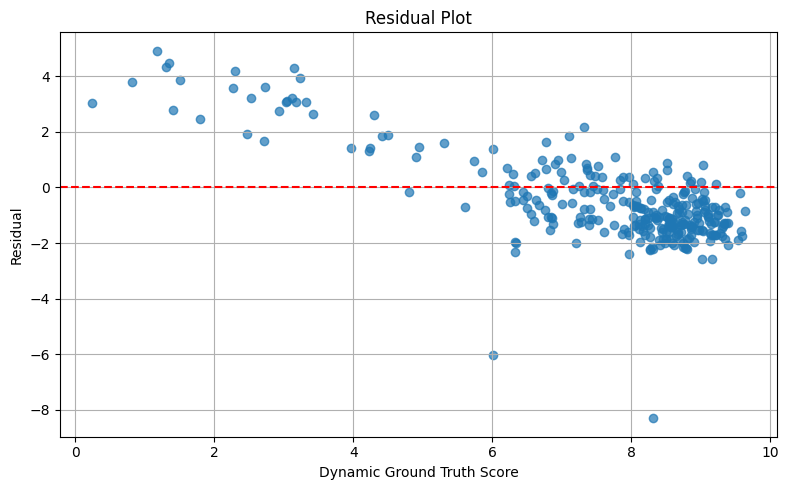

In [23]:
residuals = (
    scores_df["predicted_score"] -
    scores_df["ground_truth_score"]
)

plt.figure(figsize=(8,5))

plt.scatter(
    scores_df["ground_truth_score"],
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Dynamic Ground Truth Score")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.grid(True)

plt.tight_layout()
plt.show()